In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Flatten, LayerNormalization
from keras import optimizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
cols_to_drop = ['latitude', 'longitude', 'city']
cols = ['aqi', 'temperature_2m', 'relative_humidity_2m', 
       'wind_speed_10m', 'pressure_msl', 'precipitation', 'cloud_cover', 'pm2.5','ozone']

In [3]:
df = pd.read_csv('Data/Final/San_Jose___Jackson.csv')
df.drop(cols_to_drop, axis=1, inplace=True)
df.set_index(['date'], inplace=True)
df = df[cols]
df.head()

,aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,pressure_msl,precipitation,cloud_cover,pm2.5,ozone
date,,,,,,,,,
2014-01-01,154.0,10.993118,42.393568,8.427079,1021.341176,0.0,31.823529,60.4,0.015
2014-01-02,96.0,12.511500,41.723330,8.878908,1019.933333,0.0,44.041667,33.0,0.010
2014-01-03,95.0,14.938583,37.342059,7.806972,1017.075000,0.0,92.541667,32.6,0.010
2014-01-04,83.0,14.390667,40.825293,6.490594,1015.345833,0.0,55.375000,26.4,0.015
2014-01-05,70.0,11.257333,47.339449,7.805876,1018.612500,0.0,0.000000,19.5,0.018


### Normalize the dataset

In [4]:
minimum = []
maximum = []
minimum.append(df['aqi'].min())
maximum.append(df['aqi'].max())

cols = df.columns.values.tolist()

scaler = MinMaxScaler(feature_range=(0, 1))
df[cols] = scaler.fit_transform(df[cols])

df.head()

,aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,pressure_msl,precipitation,cloud_cover,pm2.5,ozone
date,,,,,,,,,
2014-01-01,0.736842,0.223888,0.299862,0.226908,0.658160,0.0,0.318235,0.452718,0.135417
2014-01-02,0.459330,0.277988,0.291430,0.242174,0.622135,0.0,0.440417,0.248697,0.083333
2014-01-03,0.454545,0.364465,0.236308,0.205957,0.548992,0.0,0.925417,0.245719,0.083333
2014-01-04,0.397129,0.344943,0.280131,0.161481,0.504745,0.0,0.553750,0.199553,0.135417
2014-01-05,0.334928,0.233302,0.362088,0.205920,0.588336,0.0,0.000000,0.148176,0.166667


In [5]:
lag_steps = 2
original_columns = df.columns
for lag in range(1, lag_steps + 1):
    for col in original_columns:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)

df = df.dropna()

future_steps = 7
for step in range(1, future_steps + 1):
    df[f"aqi_t+{step}"] = df["aqi"].shift(-step)


df.tail()

,aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,pressure_msl,precipitation,cloud_cover,pm2.5,ozone,aqi_lag1,...,cloud_cover_lag2,pm2.5_lag2,ozone_lag2,aqi_t+1,aqi_t+2,aqi_t+3,aqi_t+4,aqi_t+5,aqi_t+6,aqi_t+7
date,,,,,,,,,,,,,,,,,,,,,
2025-03-30,0.081340,0.293636,0.619862,0.381113,0.448875,0.084795,0.939583,0.025316,0.395833,0.157895,...,0.874583,0.049888,0.416667,0.138756,0.119617,0.205742,0.205742,NaN,NaN,NaN
2025-03-31,0.138756,0.358809,0.683611,0.218255,0.503785,0.032164,0.786250,0.041698,0.437500,0.081340,...,0.580417,0.046910,0.427083,0.119617,0.205742,0.205742,NaN,NaN,NaN,NaN
2025-04-01,0.119617,0.218367,0.709156,0.201207,0.551338,0.103801,0.603333,0.036485,0.375000,0.138756,...,0.939583,0.025316,0.395833,0.205742,0.205742,NaN,NaN,NaN,NaN,NaN
2025-04-02,0.205742,0.266765,0.678566,0.407655,0.488218,0.596491,0.640000,0.060313,0.406250,0.119617,...,0.786250,0.041698,0.437500,0.205742,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-03,0.205742,0.266765,0.678566,0.407655,0.488218,0.596491,0.640000,0.060313,0.406250,0.205742,...,0.603333,0.036485,0.375000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
#validation checks for traiv vs test etc.
columns = df.columns.values
X_columns = [col for col in columns if not col.startswith('aqi_t+')]
y_columns = [col for col in columns if col.startswith('aqi_t+')]

X = df[X_columns].values
y = df[y_columns].values


temp1 = int(0.8*len(X))
temp2 = int(0.1*len(X))

X_train = X[:temp1]
X_val = X[temp1:temp1+temp2]
X_test = X[temp1+temp2:]

y_train = y[:temp1]
y_val = y[temp1:temp1+temp2]
y_test = y[temp1+temp2:]

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(3287, 27) (410, 27) (412, 27)
(3287, 7) (410, 7) (412, 7)


In [7]:
columns = df.columns.values
X_columns = [col for col in columns if not col.startswith('aqi_t+')]
y_columns = [col for col in columns if col.startswith('aqi_t+')]

X = df[X_columns].values
y = df[y_columns].values


temp1 = int(0.8*len(X))
temp2 = int(0.1*len(X))

X_train = X[:temp1]
X_val = X[temp1:temp1+temp2]
X_test = X[temp1+temp2:]

y_train = y[:temp1]
y_val = y[temp1:temp1+temp2]
y_test = y[temp1+temp2:]

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(3287, 27) (410, 27) (412, 27)
(3287, 7) (410, 7) (412, 7)


In [8]:
look_back = lag_steps+1
length_of_col = len(original_columns)

X_train = X_train.reshape((X_train.shape[0], look_back, length_of_col))
X_test = X_test.reshape((X_test.shape[0], look_back, length_of_col))
X_val = X_val.reshape((X_val.shape[0], look_back, length_of_col))

print(X_train.shape, X_val.shape, X_test.shape)

(3287, 3, 9) (410, 3, 9) (412, 3, 9)


In [9]:
epoch = 100
model = Sequential()



model.add((LSTM(units=64, return_sequences=True, input_shape=(look_back, X_train.shape[2]), activation='relu')))
# model.add(LayerNormalization())
model.add(Dropout(0.2))
model.add((LSTM(units=32, return_sequences=True, activation='relu')))
# model.add(LayerNormalization())
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(units = 7, activation='linear'))

# learning rate with decay
adam = optimizers.Adam(learning_rate=0.001)

model.compile(loss = 'mean_squared_error', optimizer = adam)

history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epoch, batch_size=50,verbose=1, shuffle = False)
model.summary()

Epoch 1/100


/Users/vgurumurthy/Downloads/aqiprediction-main/aqipred/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0299 - val_loss: 0.0076
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0099 - val_loss: 0.0073
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0091 - val_loss: 0.0072
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0086 - val_loss: 0.0071
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0082 - val_loss: 0.0071
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0079 - val_loss: 0.0071
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0077 - val_loss: 0.0071
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0076 - val_loss: 0.0071
Epoch 9/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0075 - val_loss: 0.0071
Epoch 10/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0074 - val_loss: 0.0071
Epoch 11/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0074 - val_loss: 0.0071
Epoch 12/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0073 - val_lo

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 3, 64)          │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 3, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           679 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,119 (375.47 KB)

 Trainable params: 32,039 (125.15 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64,080 (250.32 KB)

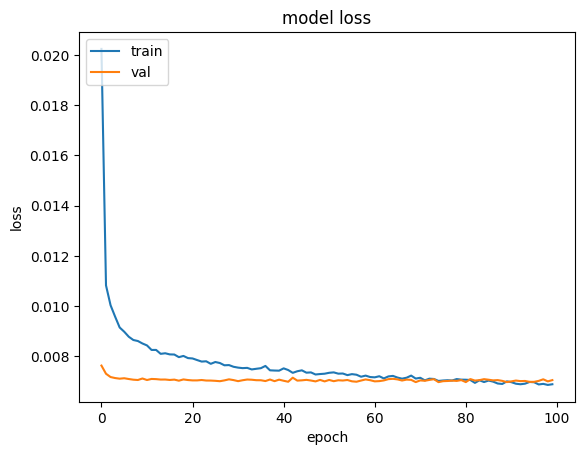

In [10]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

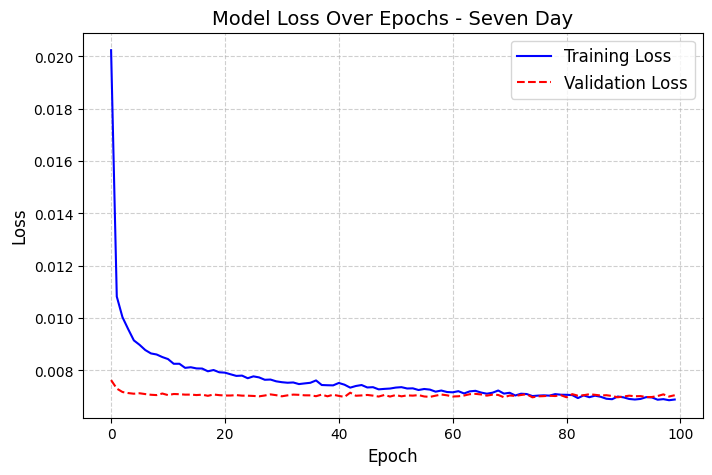

In [11]:
plt.figure(figsize=(8, 5))  # Set figure size for better readability

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss', color='blue', linestyle='solid')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='dashed')

# Titles and labels
plt.title('Model Loss Over Epochs - Seven Day', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# Add a legend and grid for clarity
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()

In [12]:
# Print final loss values for the 7-day prediction model
final_train_loss_7day = history.history['loss'][-1]
final_val_loss_7day = history.history['val_loss'][-1]

print("\nSeven-Day Prediction Model:")
print(f"Final Training Loss: {final_train_loss_7day:.4f}")
print(f"Final Validation Loss: {final_val_loss_7day:.4f}")



Seven-Day Prediction Model:
Final Training Loss: 0.0069
Final Validation Loss: 0.0071


In [13]:
predictions = model.predict(X_test, verbose=1)
predicted_df = pd.DataFrame(predictions, columns=[f"pred_aqi_t+{i+1}" for i in range(predictions.shape[1])])
actual_df = pd.DataFrame(y_test, columns=[f"actual_aqi_t+{i+1}" for i in range(y_test.shape[1])])
results_df = pd.concat([predicted_df, actual_df.reset_index(drop=True)], axis=1)

results_df = results_df * (maximum[0] - minimum[0]) + minimum[0]
results_df.index = df[-1*len(X_test):].copy().index
results_df = results_df.round(2)
final_result = results_df.copy()
results_df = results_df.dropna()
final_result.tail()


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


,pred_aqi_t+1,pred_aqi_t+2,pred_aqi_t+3,pred_aqi_t+4,pred_aqi_t+5,pred_aqi_t+6,pred_aqi_t+7,actual_aqi_t+1,actual_aqi_t+2,actual_aqi_t+3,actual_aqi_t+4,actual_aqi_t+5,actual_aqi_t+6,actual_aqi_t+7
date,,,,,,,,,,,,,,
2025-03-30,24.730000,30.110001,33.619999,36.049999,37.590000,37.529999,37.470001,29.0,25.0,43.0,43.0,NaN,NaN,NaN
2025-03-31,27.510000,29.900000,33.029999,36.189999,37.310001,36.639999,37.070000,25.0,43.0,43.0,NaN,NaN,NaN,NaN
2025-04-01,27.620001,31.559999,34.540001,36.700001,37.970001,37.889999,38.660000,43.0,43.0,NaN,NaN,NaN,NaN,NaN
2025-04-02,35.160000,36.980000,38.139999,39.119999,39.639999,39.820000,40.630001,43.0,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-03,37.480000,39.650002,40.320000,41.200001,41.320000,40.869999,41.730000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
final_result_tail = final_result.tail()  # Define the tail of final_result

# Overwrite the CSV file with final_result_tail
final_result_tail.to_csv('predictions_and_actuals_tail.csv', index=True, mode='w', header=True)


In [15]:
def calculate_metrics_from_df(results_df, actual_prefix="actual_aqi_t+", pred_prefix="pred_aqi_t+", steps=7):
    metrics = {}
    for step in range(1, steps + 1):
        actual_col = f"{actual_prefix}{step}"
        pred_col = f"{pred_prefix}{step}"
        
        if actual_col in results_df.columns and pred_col in results_df.columns:
            y_true = results_df[actual_col].values
            y_pred = results_df[pred_col].values
            
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            r2 = r2_score(y_true, y_pred) 
            metrics[f"t+{step}"] = {"RMSE": rmse, "R2": r2}
    
    return metrics

steps = 7
metrics = calculate_metrics_from_df(results_df, steps=steps)

for step, values in metrics.items():
    print(f"Metrics for {step}: RMSE = {values['RMSE']:.2f}, R² = {values['R2']:.3f}")


Metrics for t+1: RMSE = 11.91, R² = 0.432
Metrics for t+2: RMSE = 14.17, R² = 0.183
Metrics for t+3: RMSE = 15.27, R² = 0.055
Metrics for t+4: RMSE = 16.16, R² = -0.061
Metrics for t+5: RMSE = 16.91, R² = -0.161
Metrics for t+6: RMSE = 16.99, R² = -0.171
Metrics for t+7: RMSE = 16.64, R² = -0.123


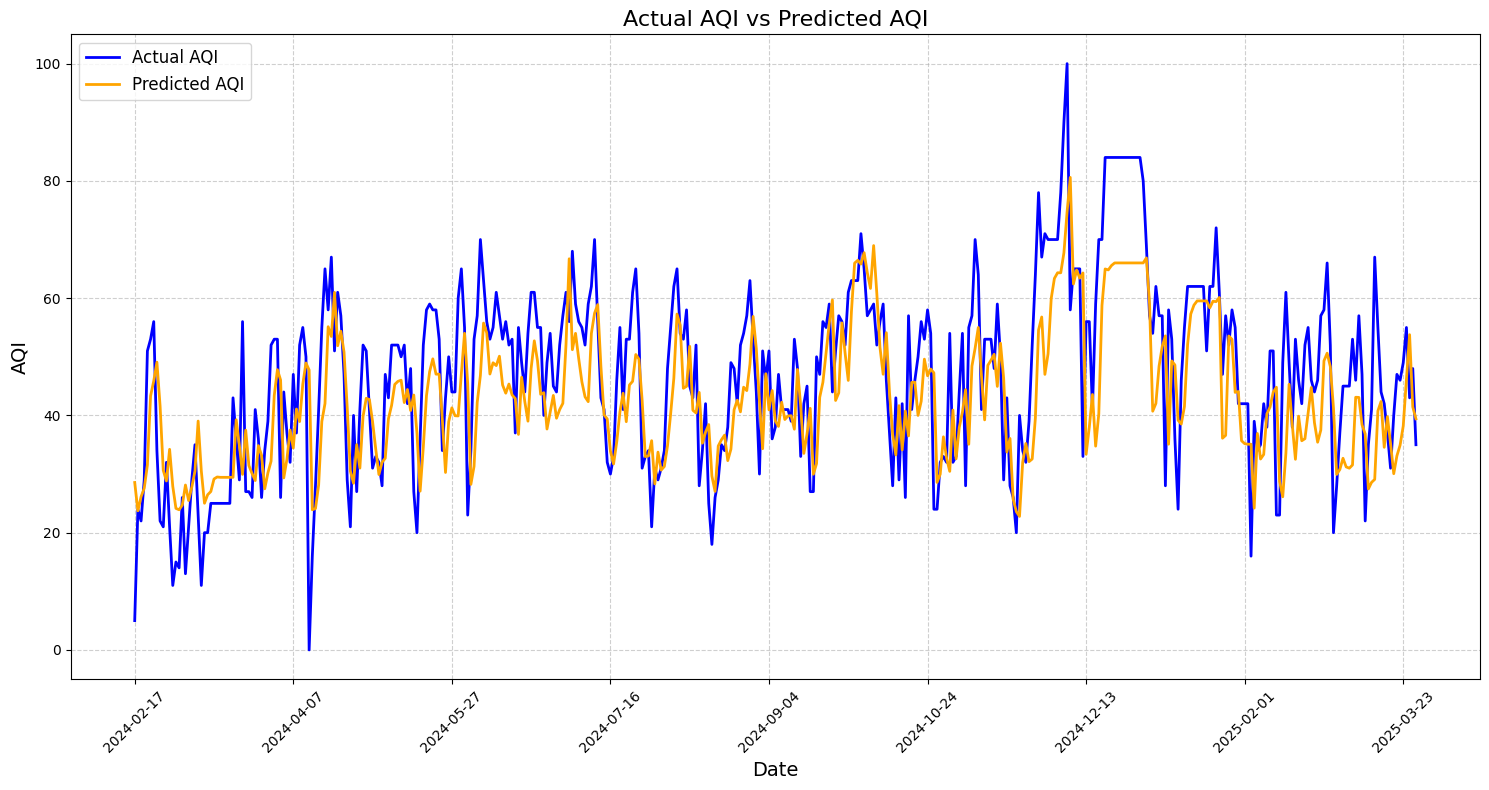

In [16]:
plt.figure(figsize=(15, 8))  # Set figure size
ax = plt.gca()  # Get the current axis

results_df['actual_aqi_t+1'].plot(ax=ax, label="Actual AQI", linestyle='-', linewidth=2, color='blue')
results_df['pred_aqi_t+1'].plot(ax=ax, label="Predicted AQI", linestyle='-', linewidth=2, color='orange')

ax.set_title("Actual AQI vs Predicted AQI", fontsize=16)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("AQI", fontsize=14)

ax.legend(loc="upper left", fontsize=12)

plt.xticks(rotation=45)

ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
results_df.index = df.index[-len(results_df):]  # Align with actual available data





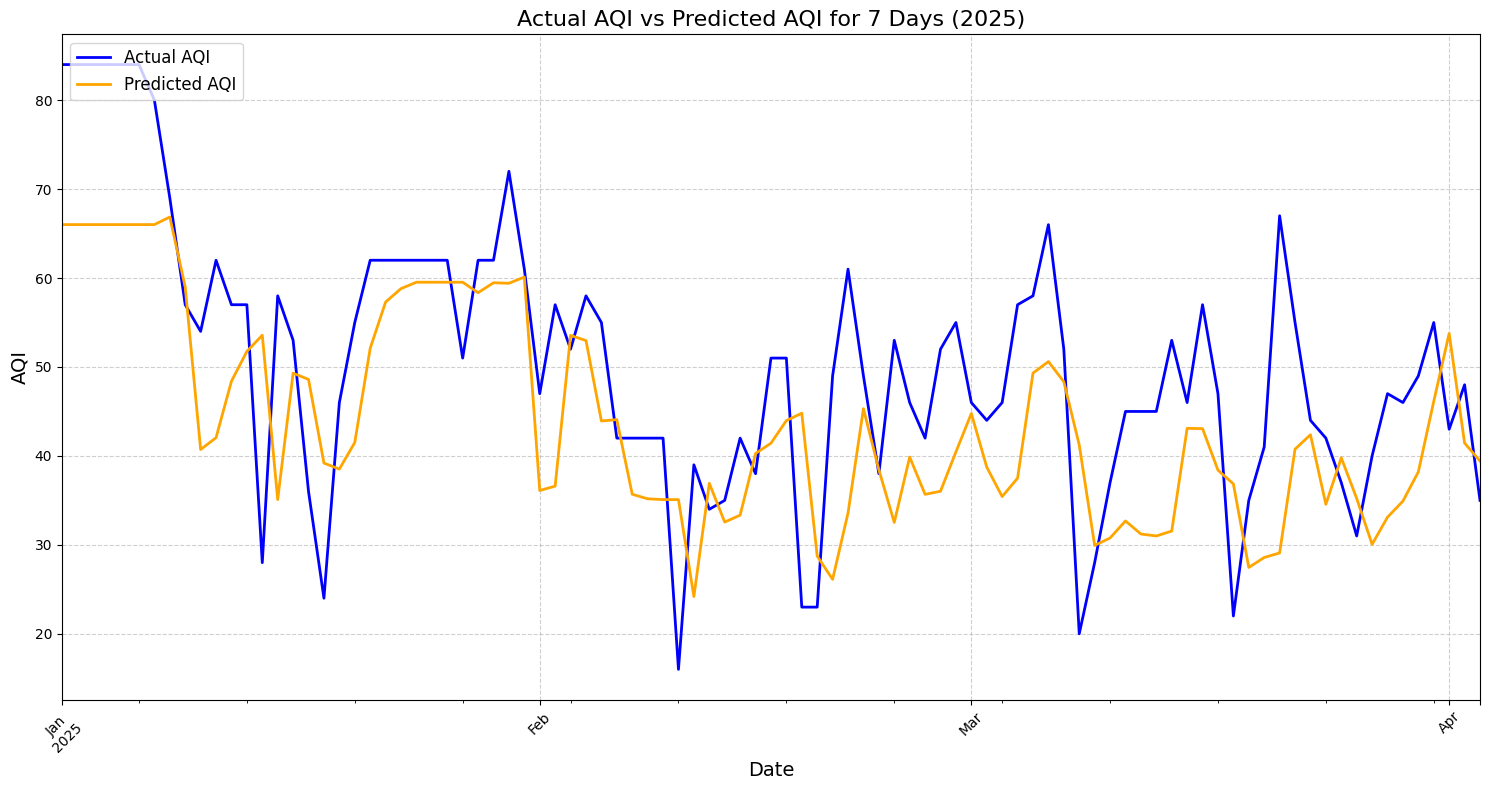

In [17]:
# Ensure the index is a DateTimeIndex
results_df.index = pd.to_datetime(results_df.index)

# Filter data from 2024 onward
results_2025 = results_df[results_df.index.year >= 2025]

# Plot Actual vs Predicted AQI from 2024 onward
plt.figure(figsize=(15, 8))  # Set figure size
ax = plt.gca()  # Get the current axis

# Plot the actual and predicted AQI values
results_2025['actual_aqi_t+1'].plot(ax=ax, label="Actual AQI", linestyle='-', linewidth=2, color='blue')
results_2025['pred_aqi_t+1'].plot(ax=ax, label="Predicted AQI", linestyle='-', linewidth=2, color='orange')

# Titles and labels
ax.set_title("Actual AQI vs Predicted AQI for 7 Days (2025)", fontsize=16)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("AQI", fontsize=14)

# Add legend and format x-axis
ax.legend(loc="upper left", fontsize=12)
plt.xticks(rotation=45)

# Add grid
ax.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()
